# Backtester V2.2 configurable — hasta 12 valores, ventanas seleccionables y fecha final

Esta versión permite fijar la fecha desde la que se cuentan hacia atrás todas las ventanas temporales. El resto de la estrategia, sus reglas de entrada y salida y sus gráficos se mantienen como en la versión 2.1.

## Uso

1. En la celda **CONFIGURACIÓN**, deja sin `#` los activos que quieras ejecutar y comenta los demás.
2. Escribe el ticker de Yahoo Finance y el capital que quieras asignarle.
3. Activa de la misma manera las ventanas temporales deseadas.
4. Configura `FECHA_FIN_VENTANA`: usa `None` o `'HOY'` para llegar hasta la fecha actual, o una fecha como `'2026-01-01'` para terminar ese día.
5. Ejecuta todas las celdas.

Si la fecha elegida no es una sesión bursátil (fin de semana o festivo), se emplea automáticamente la última sesión común anterior disponible para todos los activos.

Ejemplos de tickers: `META`, `SHOP`, `ITX.MC`, `BMW.DE`, `7203.T`, `MC.PA`, `ASML.AS`.

Los precios se normalizan a 100 para representar conjuntamente cotizaciones en dólares, euros o yenes. En el gráfico final, cada activo y el total parten de **0 %**, por lo que sus resultados son directamente comparables aunque tengan distintos capitales iniciales.

El cálculo usa precios ajustados por dividendos de forma predeterminada. No incluye comisiones, deslizamiento, impuestos, intereses del efectivo ni costes/disponibilidad del préstamo para posiciones cortas.

## Memoria experimental: salida de SHORT por RSI frente a trailing ATR

### 1. Planteamiento del problema

Las posiciones SHORT del sistema `RSI > 70` se abren cuando el activo se encuentra en una situación de fuerte impulso comprador o sobrecompra. La hipótesis es que dicho impulso no se mantendrá indefinidamente y que posteriormente aparecerá una corrección bajista. En la V2.2 original, la posición se cierra cuando el RSI del cierre anterior baja de 50; la orden de compra para cerrar se ejecuta en la apertura de la sesión siguiente.

El umbral 50 representa aproximadamente la transición desde predominio comprador hacia predominio vendedor. Por tanto, la regla original no pretende localizar el mínimo final de la caída. Su objetivo es capturar el recorrido desde la sobrecompra hasta la confirmación de presión vendedora y recoger el beneficio antes de un posible rebote.

Durante el análisis de SHOP se observó que esta regla podía cerrar una posición mientras el precio todavía continuaba bajando. Esto condujo a formular una variante denominada `CAPTURA_BAJADAS_PROGRESIVAS`.

### 2. Hipótesis de la variante

La variante sustituye la salida inmediata por RSI por el siguiente proceso:

`RSI > 70 → entrada SHORT → RSI < 50 → activar trailing BUY STOP → rebote hasta el trailing → salida`

Cuando el RSI baja de 50, la posición no se cierra. En su lugar se activa un trailing BUY STOP situado mediante la fórmula:

`Nivel trailing = mínimo desde la entrada + multiplicador ATR × ATR14`

El nivel puede desplazarse hacia abajo cuando el activo marca nuevos mínimos, pero nunca puede volver a subir. La hipótesis era que este mecanismo permitiría conservar el SHORT durante una bajada progresiva y cerrar únicamente cuando apareciese un rebote suficientemente grande. Para el experimento principal se utilizó un multiplicador de `2 ATR`.

### 3. Metodología de comparación

Se compararon ambas reglas manteniendo iguales los activos, capitales, periodo de nueve meses, señales de entrada, stop loss, deslizamiento y restantes parámetros. La muestra estaba formada por META y SHOP, con 5.000 unidades monetarias asignadas a cada activo. De esta manera, la única diferencia relevante fue la gestión de salida de los SHORT iniciados por `RSI > 70`.

Los resultados corresponden a la ventana disponible en el momento del ensayo. La última sesión de SHOP todavía podía contener información intradía, por lo que este ejercicio debe interpretarse como una comparación experimental y no como una validación definitiva fuera de muestra.

### 4. Resultados obtenidos

| Estrategia | META | SHOP | Total cartera | Drawdown cartera |
|---|---:|---:|---:|---:|
| V2.2: salida inmediata con `RSI < 50` | +39,52 % | +48,12 % | **+43,82 %** | -7,42 % |
| Trailing relajado después de `RSI < 50` (`2 ATR`) | +32,34 % | +36,33 % | **+34,33 %** | -8,75 % |

La variante de 2 ATR redujo la rentabilidad total en 9,49 puntos porcentuales y empeoró el drawdown en 1,33 puntos. En SHOP, la diferencia fue de -11,79 puntos porcentuales respecto a la regla original.

El análisis de operaciones individuales permite entender el resultado. En algunos movimientos largos el trailing consiguió una mejora: una operación de SHOP que la regla original cerraba con +16,40 % alcanzó +18,51 %. Sin embargo, en varias oscilaciones rápidas devolvió una parte importante del beneficio antes de ejecutarse: aproximadamente +3,06 % frente a +0,15 %, +10,42 % frente a +4,39 % y +7,26 % frente a +3,24 %. Además, al mantener las posiciones abiertas durante más tiempo, la variante bloqueó la posibilidad de aprovechar algunas señales posteriores.

### 5. Interpretación

La regla `RSI < 50` funciona especialmente bien cuando el activo presenta correcciones bruscas seguidas de rebotes, porque recoge el beneficio en cuanto la presión vendedora queda confirmada. Esta característica encaja con el comportamiento observado en SHOP durante la muestra: sus bajadas no siempre forman tendencias suaves y persistentes, sino que contienen oscilaciones y recuperaciones rápidas. Esperar un trailing amplio permitió que varios rebotes consumieran una parte del beneficio ya acumulado.

La salida original tiene como inconveniente que puede abandonar pronto una bajada progresiva. No obstante, intentar capturar el tramo adicional exige aceptar que se devolverá beneficio cuando el movimiento cambie de dirección. El experimento muestra que, para esta muestra y con una distancia de 2 ATR, ese coste fue superior al beneficio obtenido en las pocas caídas que continuaron.

También se realizó un análisis preliminar de sensibilidad. Un trailing mucho más estrecho, de 0,5 ATR, produjo dentro de esta misma ventana un resultado superior al original: aproximadamente +52,09 % en SHOP y +46,28 % en la cartera. Sin embargo, este dato no demuestra todavía que 0,5 ATR sea una regla mejor. Elegir el parámetro después de observar los resultados introduce riesgo de sobreajuste; sería necesario probarlo en otros periodos, activos y condiciones de mercado.

### 6. Conclusión

La V2.2 conserva como regla principal la salida de los SHORT por RSI cuando `RSI < 50`. El experimento no demuestra que todos los trailing sean ineficaces, pero sí que relajar la salida hasta `2 ATR` perjudicó de forma clara el rendimiento y el control del drawdown en la muestra estudiada.

En consecuencia, la salida original resulta una referencia más robusta para el comportamiento oscilatorio observado en SHOP: renuncia deliberadamente a capturar el final de algunas bajadas progresivas a cambio de asegurar antes las correcciones bruscas. La variante `CAPTURA_BAJADAS_PROGRESIVAS` se mantiene como experimento separado y no sustituye a la lógica base hasta completar una validación fuera de muestra.

In [1]:
# ========================= CONFIGURACIÓN GENERAL =========================
# Esta es la única sección que normalmente debe modificar el usuario.

# ACTIVOS contiene parejas formadas por el ticker de Yahoo Finance y el
# capital teórico que se asigna exclusivamente a ese valor. Para activar o
# desactivar un valor basta con quitar o añadir # al principio de su línea.
# Se admiten entre 1 y 12 valores activos.
ACTIVOS = [
    ('META',    5_000),
    ('SHOP',    5_000),
    # ('ITX.MC',  5_000),      # España
    # ('7203.T',  5_000),      # Toyota, Japón
    # ('7974.T',  5_000),      # Nintendo, Japón
    # ('BMW.DE',  5_000),      # Alemania
    # ('MC.PA',   5_000),      # LVMH, Francia
    # ('ASML.AS', 5_000),      # Países Bajos
    # ('AAPL',    5_000),
    ('NVDA',    5_000),
    ('MSFT',    5_000),
    ('AMZN',    5_000),
]

# ======================= MODO DE OPERACIÓN =======================
# Deja descomentada EXACTAMENTE UNA de las tres líneas siguientes.
# SOLO_LONG ignora todas las entradas SHORT.
# SOLO_SHORT ignora todas las entradas LONG.
# LONG_Y_SHORT conserva el comportamiento actual: una única posición por
# activo, alternando LONG o SHORT según la señal que aparezca estando libre.
# MODO_OPERATIVO = 'SOLO_LONG'
# MODO_OPERATIVO = 'SOLO_SHORT'
MODO_OPERATIVO = 'LONG_Y_SHORT'
# ================================================================

# Cada número representa la duración, en meses, de una ventana de backtest.
# Todas las ventanas terminarán en FECHA_FIN_VENTANA y contarán hacia atrás.
VENTANAS_MESES = [
    
    9
]
# Ejemplo para mostrar solo 3 y 9 meses:
# VENTANAS_MESES = [3, 9]

# NUEVO EN V2.2: extremo final común de todas las ventanas.
# - None o 'HOY': utiliza la fecha actual del ordenador.
# - Una fecha 'AAAA-MM-DD': fija el final histórico del estudio.
# Si el día no tiene cotización, se usará la última sesión común anterior.
FECHA_FIN_VENTANA = None
# FECHA_FIN_VENTANA = '2025-06-06'

# Si se deja en False, una posición aún viva al final del histórico no se
# liquida artificialmente; quedará abierta con PnL en valor de mercado hasta la
# última sesión disponible. Si se activa, se fuerza un cierre al final del
# backtest, que puede empeorar el resultado de trades que aún no han salido.
CERRAR_AL_FINAL = False

# Parámetros de cálculo y gestión del riesgo. Se conservan sin cambios.
AJUSTAR_DIVIDENDOS = True
STOP_LONG = 0.07                 # Stop de una posición larga: 7 %.
STOP_SHORT = 0.07                # Stop de una posición corta: 7 %.
DESLIZAMIENTO_BPS = 5             # 5 pb por ejecución (0.05 %); ajuste conservador.
PERIODO_RUPTURA = 20             # Sesiones usadas para detectar una ruptura.
MULTIPLICADOR_VOLUMEN = 1.00     # Volumen mínimo frente a su media previa.
RUPTURA_ATR = 2.0                # Distancia del trailing stop en múltiplos ATR.
RUPTURA_MAX_SESIONES = 20        # Duración máxima de un corto por ruptura.
# ========================================================================


In [2]:
# ==================== IMPORTACIÓN Y PREPARACIÓN DE DATOS ====================
# Librerías estándar: avisos, carpeta temporal y manejo de rutas.
import warnings
import tempfile
from pathlib import Path

# relativedelta resta meses naturales (no un número aproximado de días).
from dateutil.relativedelta import relativedelta

# Librerías de cálculo, tablas, gráficos y descarga de cotizaciones.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import yfinance as yf
from IPython import get_ipython
from IPython.display import display

# Se ocultan avisos no críticos para que la salida del cuaderno sea legible.
warnings.filterwarnings('ignore')

# yfinance guarda su caché de zonas horarias en la carpeta temporal del sistema.
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_backtester_v22_config_cache'))

# Activa los gráficos integrados solo cuando el código se ejecuta en Jupyter.
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

# ---------------------- Validación de la configuración ----------------------
# Estas comprobaciones detienen pronto el programa y muestran un mensaje claro
# si el usuario ha escrito una configuración imposible o ambigua.
if not 1 <= len(ACTIVOS) <= 12:
    raise ValueError('Debes activar entre 1 y 12 valores.')

# Se normalizan los tickers a mayúsculas y se crea un diccionario ticker-capital.
tickers = [str(t).strip().upper() for t, _ in ACTIVOS]
capitales = {str(t).strip().upper(): float(c) for t, c in ACTIVOS}
if len(set(tickers)) != len(tickers):
    raise ValueError('No puede haber tickers duplicados en ACTIVOS.')
if any(c <= 0 for c in capitales.values()):
    raise ValueError('Todos los capitales deben ser mayores que cero.')
MODO_OPERATIVO = str(MODO_OPERATIVO).strip().upper()
MODOS_VALIDOS = {'SOLO_LONG', 'SOLO_SHORT', 'LONG_Y_SHORT'}
if MODO_OPERATIVO not in MODOS_VALIDOS:
    raise ValueError(
        "MODO_OPERATIVO debe ser 'SOLO_LONG', 'SOLO_SHORT' o 'LONG_Y_SHORT'."
    )
if not VENTANAS_MESES or any(not isinstance(m, int) or m <= 0 for m in VENTANAS_MESES):
    raise ValueError('VENTANAS_MESES debe contener enteros positivos.')

# Se eliminan ventanas repetidas y se ordenan de menor a mayor.
VENTANAS_MESES = sorted(set(VENTANAS_MESES))

# ---------------------- Resolución de la fecha final V2.2 -------------------
# None y el texto HOY significan lo mismo: la fecha actual, sin hora.
if FECHA_FIN_VENTANA is None or str(FECHA_FIN_VENTANA).strip().upper() == 'HOY':
    fecha_fin_solicitada = pd.Timestamp.today().normalize()
else:
    try:
        fecha_fin_solicitada = pd.Timestamp(FECHA_FIN_VENTANA).normalize()
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "FECHA_FIN_VENTANA debe ser None, 'HOY' o una fecha válida 'AAAA-MM-DD'."
        ) from exc

# No se admiten fechas futuras porque todavía no existen cotizaciones para ellas.
hoy = pd.Timestamp.today().normalize()
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN_VENTANA no puede ser posterior a la fecha actual.')

# Se descargan cinco meses extra antes de la ventana mayor. Ese margen permite
# calcular RSI, Bollinger, EMA, ATR y medias sin perder el inicio del backtest.
max_meses = max(VENTANAS_MESES)
inicio_descarga = fecha_fin_solicitada - relativedelta(months=max_meses + 5)

datos_raw = {}
errores = []

# BUCLE DE DESCARGA: recorre una vez cada ticker activo, descarga sus velas
# diarias, homogeneiza columnas/fechas y guarda el DataFrame ya limpio.
for ticker in tickers:
    try:
        # yfinance interpreta end como límite exclusivo; se suma un día para
        # incluir FECHA_FIN_VENTANA cuando esta sea una sesión bursátil.
        d = yf.download(
            ticker,
            start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d',
            auto_adjust=AJUSTAR_DIVIDENDOS,
            progress=False,
            threads=False
        )

        # Algunas versiones de yfinance devuelven columnas multinivel incluso
        # al pedir un único ticker. Aquí se convierten en columnas sencillas.
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)

        # Solo se conservan los campos OHLCV que utiliza la estrategia.
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()

        # Se eliminan zona horaria y hora para comparar únicamente fechas.
        if getattr(d.index, 'tz', None) is not None:
            d.index = d.index.tz_localize(None)
        d.index = pd.to_datetime(d.index).normalize()
        d = d[~d.index.duplicated(keep='last')].sort_index()

        # Sesenta sesiones son el mínimo prudente para indicadores y backtest.
        if len(d) < 60:
            raise ValueError(f'solo se recibieron {len(d)} sesiones')
        datos_raw[ticker] = d
    except Exception as exc:
        # No se interrumpe el bucle: se recopilan todos los fallos para informar
        # juntos al usuario al terminar de intentar las descargas.
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error descargando datos:\n' + '\n'.join(errores))

# Cada mercado puede tener festivos distintos. El mínimo de sus últimas fechas
# garantiza que todos los activos terminan en una sesión realmente compartida.
ultima_fecha_comun = min(d.index.max() for d in datos_raw.values())

print('Valores activos:', ', '.join(f'{t} ({capitales[t]:,.2f})' for t in tickers))
print('Modo operativo:', MODO_OPERATIVO)
print('Ventanas activas:', ', '.join(f'{m} meses' for m in VENTANAS_MESES))
print('Fecha final solicitada:', fecha_fin_solicitada.date())
print('Última sesión común utilizada:', ultima_fecha_comun.date())

Valores activos: META (5,000.00), SHOP (5,000.00), NVDA (5,000.00), MSFT (5,000.00), AMZN (5,000.00)
Modo operativo: LONG_Y_SHORT
Ventanas activas: 9 meses
Fecha final solicitada: 2026-09-01
Última sesión común utilizada: 2026-09-01


In [3]:
# ========================= CÁLCULO DE INDICADORES =========================
def preparar_senales(df):
    """Añade al histórico todos los indicadores y señales de la estrategia."""
    d = df.copy()

    # RSI de 14 sesiones: separa variaciones positivas y negativas y compara
    # sus medias. Valores bajos sugieren sobreventa y altos, sobrecompra.
    delta = d['Close'].diff()
    subida = delta.clip(lower=0)
    bajada = -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)

    # Bandas de Bollinger: media de 20 sesiones más/menos dos desviaciones.
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desviacion = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desviacion

    # EMA10: media exponencial que da más peso a cierres recientes.
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()

    # ATR14: mide volatilidad mediante el mayor de tres rangos diarios posibles.
    cierre_previo = d['Close'].shift(1)
    rangos_reales = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - cierre_previo).abs(),
        (d['Low'] - cierre_previo).abs()
    ], axis=1)
    tr = rangos_reales.max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()

    # Señales LONG: se entra por sobreventa y se sale al normalizarse precio/RSI.
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])

    # Las referencias de ruptura se desplazan una sesión para evitar usar datos
    # del propio día que produce la señal (evita sesgo de anticipación).
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)

    # Señales SHORT: sobrecompra por RSI o ruptura de mínimos con volumen.
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (
        (d['Close'] < d['MINIMO_20_PREV'])
        & (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )
    return d


# COMPRENSIÓN POR TICKER: ejecuta la función anterior para cada activo y limita
# sus datos a la última sesión común, de modo que todos sean comparables.
datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}

In [4]:
# ================= MOTOR DE BACKTEST PARA UN ACTIVO =================
def ejecutar_v22(ticker, fecha_inicio, capital_inicial):
    """Simula un ticker entre fecha_inicio y la fecha final común.

    Las señales se calculan tras el cierre y las órdenes se ejecutan en la
    apertura siguiente. Los stops quedan activos durante la sesión y los
    gaps se rellenan a la apertura, nunca a un precio ya atravesado.
    """
    d = datos[ticker]
    fechas = d.index[(d.index >= fecha_inicio) & (d.index <= ultima_fecha_comun)]
    if len(fechas) < 2:
        raise ValueError(f'{ticker}: datos insuficientes para la ventana solicitada.')

    # Estado de la simulación. posicion vale None cuando no hay operación.
    capital = float(capital_inicial)
    posicion = None
    operaciones = []
    equity = []
    minimo_desde_entrada = np.inf
    trailing = np.inf
    sesiones = 0
    deslizamiento = DESLIZAMIENTO_BPS / 10_000

    def precio_con_deslizamiento(precio, lado):
        """Empeora el precio teórico para aproximar spread y deslizamiento."""
        factor = 1 + deslizamiento if lado == 'COMPRA' else 1 - deslizamiento
        return float(precio) * factor

    def cerrar(fecha, salida, motivo):
        """Cierra la posición abierta y actualiza capital e historial."""
        nonlocal capital, posicion

        # Un LONG gana si sube; un SHORT gana si el precio baja.
        if posicion['Tipo'] == 'LONG':
            retorno = (salida - posicion['Precio entrada']) / posicion['Precio entrada']
        else:
            retorno = (posicion['Precio entrada'] - salida) / posicion['Precio entrada']

        # Se reinvierte el capital completo: el rendimiento es compuesto.
        capital *= 1 + retorno
        operaciones.append({
            **posicion,
            'Salida': fecha,
            'Precio salida': salida,
            'Rentabilidad %': retorno * 100,
            'Motivo': motivo
        })
        posicion = None

    # BUCLE PRINCIPAL DE SESIONES: avanza cronológicamente día a día. En cada
    # iteración primero gestiona una posición existente, después estudia una
    # nueva entrada y finalmente registra el valor diario de la cartera.
    for fecha in fechas:
        i = d.index.get_loc(fecha)
        fila = d.iloc[i]                    # Precios de la sesión ejecutada.
        senal = d.iloc[i - 1] if i > 0 else None  # Señal del cierre anterior.
        apertura, maximo, minimo, cierre = map(
            float, [fila['Open'], fila['High'], fila['Low'], fila['Close']]
        )
        estaba_abierta = posicion is not None

        # 1) SALIDAS CONOCIDAS EN LA APERTURA. Las decisiones tomadas tras el
        # cierre anterior se ejecutan antes de consultar High/Low de hoy.
        if posicion is not None and senal is not None:
            entrada = posicion['Precio entrada']

            if posicion['Tipo'] == 'LONG':
                if bool(senal['LONG_EXIT']):
                    salida = precio_con_deslizamiento(apertura, 'VENTA')
                    cerrar(fecha, salida, 'SEÑAL SALIDA LONG')

            elif posicion['Sistema entrada'] != 'RUPTURA':
                if bool(senal['RSI'] < 50):
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'SEÑAL SALIDA SHORT')

            else:
                # Todas estas condiciones usan exclusivamente cierres ya
                # conocidos y, por tanto, se ejecutan en la apertura.
                recupera_ema = (
                    i >= 2
                    and bool((d['Close'].iloc[i - 2:i] > d['EMA10'].iloc[i - 2:i]).all())
                )
                if recupera_ema:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'DOS CIERRES SOBRE EMA10')
                elif bool(senal['RSI'] > 55):
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'RSI > 55')
                elif sesiones >= RUPTURA_MAX_SESIONES:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'MÁXIMO 20 SESIONES')

        # 2) STOPS QUE ESTABAN ACTIVOS AL ABRIR. Un gap que atraviesa el stop
        # se ejecuta a la apertura; si se toca después, se usa el nivel stop.
        if posicion is not None and estaba_abierta:
            entrada = posicion['Precio entrada']
            if posicion['Tipo'] == 'LONG':
                stop_activo = entrada * (1 - STOP_LONG)
                if apertura <= stop_activo:
                    salida = precio_con_deslizamiento(apertura, 'VENTA')
                    cerrar(fecha, salida, 'STOP LOSS LONG - GAP')
                elif minimo <= stop_activo:
                    salida = precio_con_deslizamiento(stop_activo, 'VENTA')
                    cerrar(fecha, salida, 'STOP LOSS LONG')
            else:
                stop_activo = entrada * (1 + STOP_SHORT)
                if posicion['Sistema entrada'] == 'RUPTURA':
                    stop_activo = min(stop_activo, trailing)
                if apertura >= stop_activo:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'STOP SHORT - GAP')
                elif maximo >= stop_activo:
                    salida = precio_con_deslizamiento(stop_activo, 'COMPRA')
                    motivo = 'STOP/TRAILING RUPTURA' if posicion['Sistema entrada'] == 'RUPTURA' else 'STOP LOSS SHORT'
                    cerrar(fecha, salida, motivo)

        # 3) GESTIÓN DE ENTRADAS. No se abre otra operación en la misma apertura
        # en la que se cerró una anterior, evitando dos decisiones simultáneas.
        if posicion is None and not estaba_abierta and senal is not None:
            if MODO_OPERATIVO != 'SOLO_SHORT' and bool(senal['LONG_ENTRY']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'LONG',
                    'Sistema entrada': 'RSI + BOLLINGER',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'COMPRA')
                }
            elif MODO_OPERATIVO != 'SOLO_LONG' and bool(senal['SHORT_RUPTURA']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'SHORT',
                    'Sistema entrada': 'RUPTURA',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'VENTA')
                }
            elif MODO_OPERATIVO != 'SOLO_LONG' and bool(senal['SHORT_RSI']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'SHORT',
                    'Sistema entrada': 'RSI > 70',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'VENTA')
                }

            # Inicializa las variables auxiliares de cualquier nueva posición.
            if posicion is not None:
                minimo_desde_entrada = posicion['Precio entrada']
                trailing = posicion['Precio entrada'] * (1 + STOP_SHORT)
                sesiones = 0

                # La orden bracket queda activa tras ejecutarse la entrada.
                entrada = posicion['Precio entrada']
                stop_activo = entrada * (1 - STOP_LONG) if posicion['Tipo'] == 'LONG' else entrada * (1 + STOP_SHORT)
                toca_stop = minimo <= stop_activo if posicion['Tipo'] == 'LONG' else maximo >= stop_activo
                if toca_stop:
                    lado = 'VENTA' if posicion['Tipo'] == 'LONG' else 'COMPRA'
                    salida = precio_con_deslizamiento(stop_activo, lado)
                    cerrar(fecha, salida, 'STOP MISMA SESIÓN DE ENTRADA')

        # 4) ACTUALIZACIÓN AL CIERRE. El nuevo trailing utiliza solo datos ya
        # cerrados y no estará activo hasta la apertura de la sesión siguiente.
        if posicion is not None and posicion['Sistema entrada'] == 'RUPTURA':
            sesiones += 1
            minimo_desde_entrada = min(minimo_desde_entrada, minimo)
            if pd.notna(fila['ATR14']):
                candidato = minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14'])
                trailing = min(trailing, candidato)

        # 5) VALORACIÓN DIARIA. Con posición abierta se añade la ganancia o
        # pérdida latente al capital; sin posición, el valor coincide con caja.
        valor = capital
        if posicion is not None:
            entrada = posicion['Precio entrada']
            if posicion['Tipo'] == 'LONG':
                retorno_abierto = (cierre - entrada) / entrada
            else:
                retorno_abierto = (entrada - cierre) / entrada
            valor = capital * (1 + retorno_abierto)
        equity.append({'Fecha': fecha, 'Equity': valor})

    # El fin de los datos no es una señal de salida. Por defecto la posición
    # permanece abierta y se valora al último cierre disponible, sin añadir una
    # operación ficticia ni una fecha/marcador de salida.
    posicion_abierta = None
    if posicion is not None and CERRAR_AL_FINAL:
        ultimo_cierre = float(d.loc[fechas[-1], 'Close'])
        lado = 'VENTA' if posicion['Tipo'] == 'LONG' else 'COMPRA'
        salida = precio_con_deslizamiento(ultimo_cierre, lado)
        cerrar(fechas[-1], salida, 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital
    elif posicion is not None:
        ultimo_cierre = float(d.loc[fechas[-1], 'Close'])
        entrada = posicion['Precio entrada']
        if posicion['Tipo'] == 'LONG':
            retorno_latente = (ultimo_cierre - entrada) / entrada
        else:
            retorno_latente = (entrada - ultimo_cierre) / entrada
        posicion_abierta = {
            **posicion,
            'Estado': 'ABIERTA',
            'Fecha valoración': fechas[-1],
            'Precio valoración': ultimo_cierre,
            'Rentabilidad latente %': retorno_latente * 100,
            'Capital valorado': capital * (1 + retorno_latente)
        }

    # El drawdown es la peor caída porcentual desde un máximo previo de equity.
    eq = pd.DataFrame(equity).set_index('Fecha')
    if eq.empty:
        eq = pd.DataFrame({'Equity': [float(capital_inicial)]}, index=pd.DatetimeIndex([fechas[0]]))
    dd = (eq['Equity'] / eq['Equity'].cummax() - 1).min() * 100

    return {
        'Ticker': ticker,
        'Capital inicial': capital_inicial,
        'Capital realizado': capital,
        'Capital final': float(eq['Equity'].iloc[-1]),
        'Rentabilidad %': (float(eq['Equity'].iloc[-1]) / capital_inicial - 1) * 100,
        'Posición abierta': posicion_abierta,
        'Drawdown máximo %': dd,
        'Operaciones': operaciones,
        'Equity': eq,
        'Fecha inicio': fechas[0],
        'Fecha fin': fechas[-1]
    }

In [5]:
# ================= EJECUCIÓN DE TODAS LAS VENTANAS =================
resultados = {}  # Estructura anidada: resultados[meses][ticker].
filas = []       # Registros que después formarán la tabla comparativa.

# BUCLE EXTERIOR: crea una simulación independiente por cada duración elegida.
# La fecha inicial se calcula hacia atrás desde la fecha final común de V2.2.
for meses in VENTANAS_MESES:
    fecha_objetivo = ultima_fecha_comun - relativedelta(months=meses)
    resultados[meses] = {}
    bh_finales = []
    entradas_estrategia = []
    salidas_estrategia = []

    # BUCLE INTERIOR: dentro de la ventana actual ejecuta todos los tickers con
    # su propio capital. Los activos no comparten dinero ni posiciones.
    for ticker in tickers:
        r = ejecutar_v22(ticker, fecha_objetivo, capitales[ticker])
        resultados[meses][ticker] = r
        ops = pd.DataFrame(r['Operaciones'])
        abierta = r['Posición abierta']

        # Buy & Hold comparable: mismo capital, primera apertura y último
        # cierre de la ventana, incluyendo el mismo deslizamiento de ida/vuelta.
        d_bh = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        coste_bh = float(d_bh['Open'].iloc[0]) * (1 + DESLIZAMIENTO_BPS / 10_000)
        venta_bh = float(d_bh['Close'].iloc[-1]) * (1 - DESLIZAMIENTO_BPS / 10_000)
        rentabilidad_bh = (venta_bh / coste_bh - 1) * 100
        capital_final_bh = r['Capital inicial'] * (1 + rentabilidad_bh / 100)
        bh_finales.append(capital_final_bh)

        entradas = list(ops['Entrada']) if not ops.empty else []
        if abierta is not None:
            entradas.append(abierta['Entrada'])
        primera_entrada = min(entradas) if entradas else pd.NaT
        ultima_salida = ops['Salida'].max() if not ops.empty else pd.NaT
        if pd.notna(primera_entrada):
            entradas_estrategia.append(primera_entrada)
        if pd.notna(ultima_salida):
            salidas_estrategia.append(ultima_salida)

        # Cada diccionario será una fila de resultados para activo y ventana.
        filas.append({
            'Ventana (meses)': meses,
            'Ticker': ticker,
            'Capital inicial': r['Capital inicial'],
            'Capital realizado': r['Capital realizado'],
            'Capital final': r['Capital final'],
            'Beneficio': r['Capital final'] - r['Capital inicial'],
            'Rentabilidad %': r['Rentabilidad %'],
            'Primera entrada': primera_entrada,
            'Última salida': ultima_salida,
            'Entrada B&H': r['Fecha inicio'],
            'Salida B&H': r['Fecha fin'],
            'Capital final B&H': capital_final_bh,
            'Rentabilidad B&H %': rentabilidad_bh,
            'Ventaja vs B&H (pp)': r['Rentabilidad %'] - rentabilidad_bh,
            'Drawdown máximo %': r['Drawdown máximo %'],
            'Posición abierta': '' if abierta is None else abierta['Tipo'],
            'PnL latente %': np.nan if abierta is None else abierta['Rentabilidad latente %'],
            'Operaciones cerradas': len(ops),
            'Acierto %': ops['Rentabilidad %'].gt(0).mean() * 100 if not ops.empty else 0
        })

    # Las curvas individuales se alinean por fecha y se suman para construir la
    # cartera. ffill conserva el último valor conocido cuando falta una sesión.
    curvas = [
        r['Equity']['Equity'].rename(ticker)
        for ticker, r in resultados[meses].items()
    ]
    total_eq = pd.concat(curvas, axis=1).sort_index().ffill().dropna().sum(axis=1)
    capital_total = sum(capitales.values())
    final_total = float(total_eq.iloc[-1])
    final_total_bh = float(sum(bh_finales))
    dd_total = (total_eq / total_eq.cummax() - 1).min() * 100
    rentabilidad_total = (final_total / capital_total - 1) * 100
    rentabilidad_total_bh = (final_total_bh / capital_total - 1) * 100

    # Se añade una fila resumen ponderada por el capital real de cada activo.
    filas.append({
        'Ventana (meses)': meses,
        'Ticker': 'TOTAL CARTERA',
        'Capital inicial': capital_total,
        'Capital realizado': sum(r['Capital realizado'] for r in resultados[meses].values()),
        'Capital final': final_total,
        'Beneficio': final_total - capital_total,
        'Rentabilidad %': rentabilidad_total,
        'Primera entrada': min(entradas_estrategia) if entradas_estrategia else pd.NaT,
        'Última salida': max(salidas_estrategia) if salidas_estrategia else pd.NaT,
        'Entrada B&H': min(r['Fecha inicio'] for r in resultados[meses].values()),
        'Salida B&H': max(r['Fecha fin'] for r in resultados[meses].values()),
        'Capital final B&H': final_total_bh,
        'Rentabilidad B&H %': rentabilidad_total_bh,
        'Ventaja vs B&H (pp)': rentabilidad_total - rentabilidad_total_bh,
        'Drawdown máximo %': dd_total,
        'Posición abierta': ', '.join(
            f"{ticker} {r['Posición abierta']['Tipo']}"
            for ticker, r in resultados[meses].items()
            if r['Posición abierta'] is not None
        ),
        'PnL latente %': np.nan,
        'Operaciones cerradas': sum(len(r['Operaciones']) for r in resultados[meses].values()),
        'Acierto %': np.nan
    })
    resultados[meses]['TOTAL CARTERA'] = {'Equity': total_eq.to_frame('Equity')}

# Conversión de registros en una tabla con índice doble: ventana y ticker.
tabla = pd.DataFrame(filas).set_index(['Ventana (meses)', 'Ticker'])
print(f'TABLA COMPARATIVA — {MODO_OPERATIVO} FRENTE A BUY & HOLD')

# El formateo afecta solo a la presentación. La fila total se resalta para que
# pueda distinguirse rápidamente de los resultados de valores individuales.
display(tabla.style.format({
    'Capital inicial': '{:,.2f}',
    'Capital realizado': '{:,.2f}',
    'Capital final': '{:,.2f}',
    'Beneficio': '{:+,.2f}',
    'Rentabilidad %': '{:+.2f}%',
    'Primera entrada': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Última salida': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Entrada B&H': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Salida B&H': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Capital final B&H': '{:,.2f}',
    'Rentabilidad B&H %': '{:+.2f}%',
    'Ventaja vs B&H (pp)': '{:+.2f}',
    'Drawdown máximo %': '{:+.2f}%',
    'PnL latente %': lambda x: '' if pd.isna(x) else f'{x:+.2f}%',
    'Acierto %': lambda x: '' if pd.isna(x) else f'{x:.1f}%'
}).apply(
    lambda fila: ['font-weight:bold;background-color:#fff3cd'] * len(fila)
    if fila.name[1] == 'TOTAL CARTERA' else [''] * len(fila),
    axis=1
))

# --------------------- Detalle simplificado de operaciones ---------------------
# Se muestra justo debajo del resumen. La numeración se reinicia para cada
# combinación de ventana y ticker.
detalle_operaciones = []
for meses in VENTANAS_MESES:
    for ticker in tickers:
        for numero, op in enumerate(resultados[meses][ticker]['Operaciones'], start=1):
            detalle_operaciones.append({
                'Ventana': f'{meses} meses',
                'Ticker': ticker,
                'Operación': numero,
                'Tipo de operación': f"{op['Tipo']} — {op['Sistema entrada']}",
                'Fec. entrada': op['Entrada'],
                'Fec. salida': op['Salida'],
                'Estado': 'CERRADA',
                'Ganancia %': op['Rentabilidad %'],
                'Motivo': op['Motivo']
            })

        abierta = resultados[meses][ticker]['Posición abierta']
        if abierta is not None:
            detalle_operaciones.append({
                'Ventana': f'{meses} meses',
                'Ticker': ticker,
                'Operación': len(resultados[meses][ticker]['Operaciones']) + 1,
                'Tipo de operación': f"{abierta['Tipo']} — {abierta['Sistema entrada']}",
                'Fec. entrada': abierta['Entrada'],
                'Fec. salida': pd.NaT,
                'Estado': 'ABIERTA',
                'Ganancia %': abierta['Rentabilidad latente %'],
                'Motivo': 'SIN SEÑAL DE SALIDA'
            })

tabla_operaciones = pd.DataFrame(detalle_operaciones)
print('\nDETALLE SIMPLIFICADO DE TODAS LAS OPERACIONES')
if tabla_operaciones.empty:
    print('No se generaron operaciones en las ventanas seleccionadas.')
else:
    display(
        tabla_operaciones.style
        .format({
            'Fec. entrada': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
            'Fec. salida': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
            'Ganancia %': '{:+.2f}%'
        })
        .map(
            lambda x: 'color:#087830;font-weight:bold' if x > 0
            else ('color:#b42318;font-weight:bold' if x < 0 else ''),
            subset=['Ganancia %']
        )
        .hide(axis='index')
    )

TABLA COMPARATIVA — LONG_Y_SHORT FRENTE A BUY & HOLD



DETALLE SIMPLIFICADO DE TODAS LAS OPERACIONES


Ventana,Ticker,Operación,Tipo de operación,Fec. entrada,Fec. salida,Estado,Ganancia %,Motivo
9 meses,META,1,SHORT — RSI > 70,2025-12-05,2025-12-12,CERRADA,-7.05%,STOP LOSS SHORT
9 meses,META,2,SHORT — RUPTURA,2026-01-14,2026-01-22,CERRADA,-0.64%,STOP/TRAILING RUPTURA
9 meses,META,3,SHORT — RSI > 70,2026-01-30,2026-02-13,CERRADA,+11.24%,SEÑAL SALIDA SHORT
9 meses,META,4,SHORT — RUPTURA,2026-03-16,2026-03-31,CERRADA,+11.35%,STOP/TRAILING RUPTURA
9 meses,META,5,SHORT — RSI > 70,2026-04-17,2026-05-01,CERRADA,+9.33%,SEÑAL SALIDA SHORT
9 meses,META,6,SHORT — RUPTURA,2026-06-12,2026-06-15,CERRADA,-4.48%,STOP/TRAILING RUPTURA
9 meses,META,7,SHORT — RSI > 70,2026-07-16,2026-07-27,CERRADA,+10.25%,SEÑAL SALIDA SHORT
9 meses,META,8,LONG — RSI + BOLLINGER,2026-07-31,2026-08-27,CERRADA,+5.94%,SEÑAL SALIDA LONG
9 meses,SHOP,1,SHORT — RSI > 70,2025-12-11,2026-01-02,CERRADA,+3.06%,SEÑAL SALIDA SHORT
9 meses,SHOP,2,LONG — RSI + BOLLINGER,2026-01-21,2026-01-23,CERRADA,-7.05%,STOP LOSS LONG


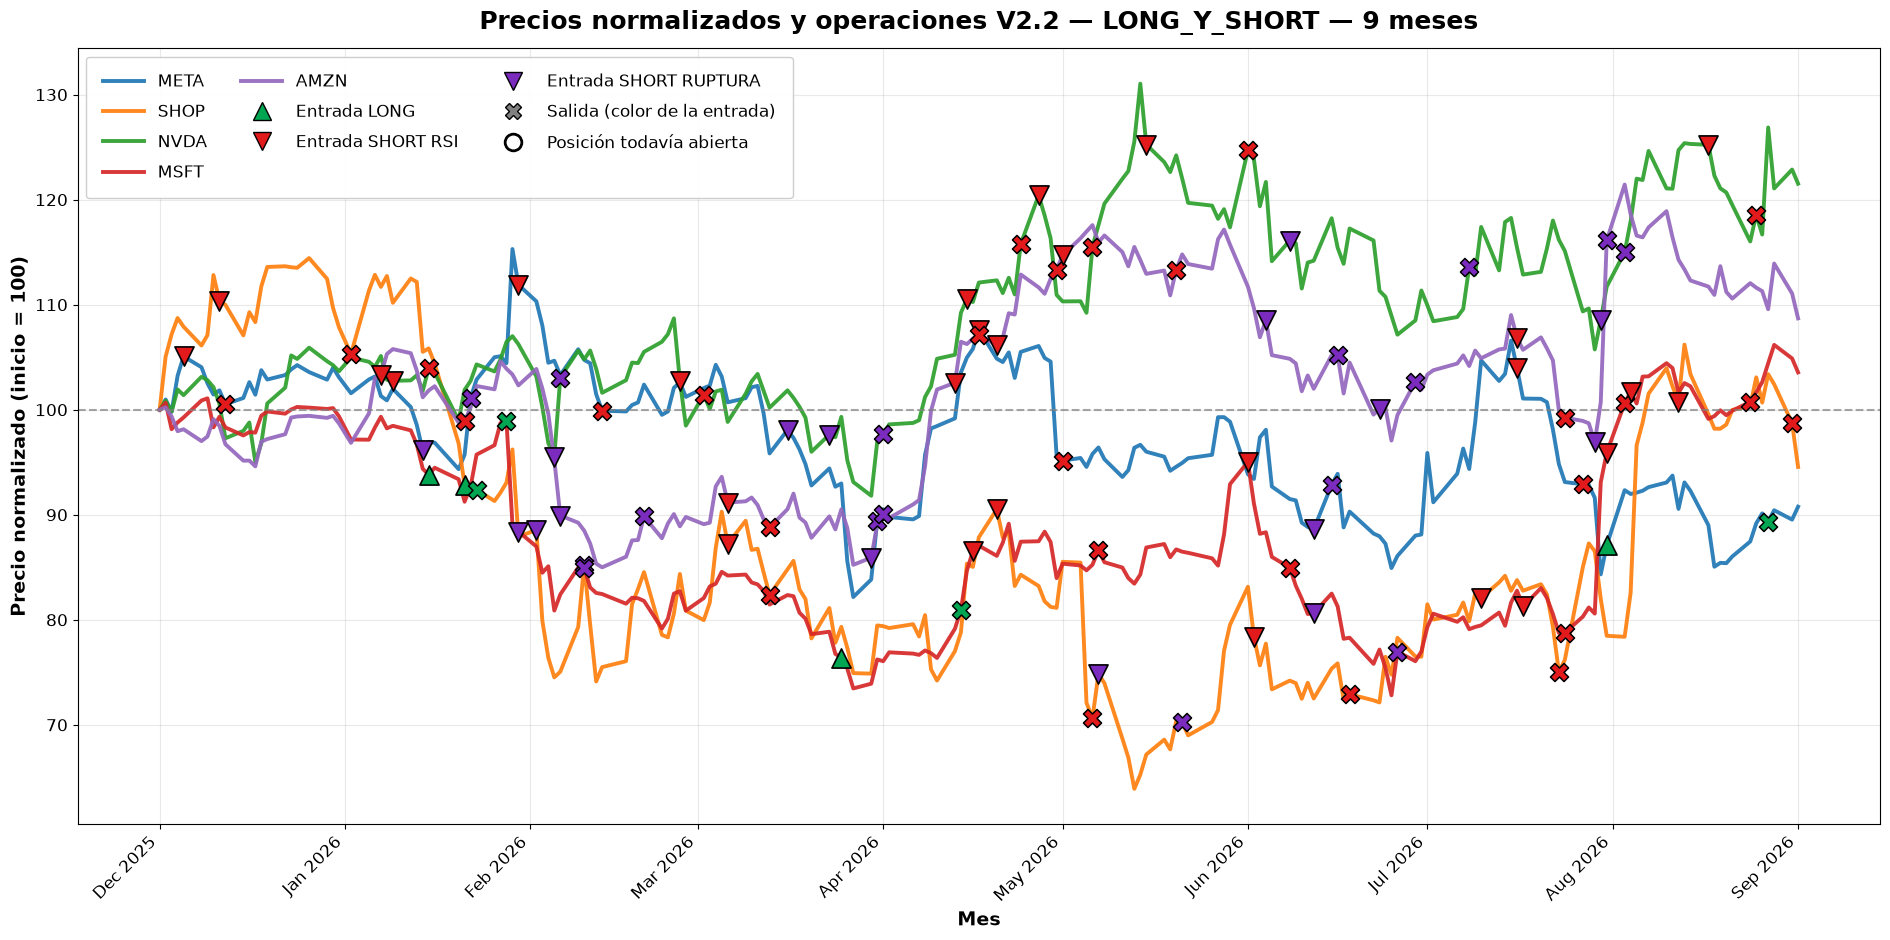

In [6]:
# ================= GRÁFICOS DE PRECIOS Y OPERACIONES =================
# A cada ticker se le asigna un color estable en todos los gráficos.
paleta = plt.get_cmap('tab10')
colores = {ticker: paleta(i % 10) for i, ticker in enumerate(tickers)}

# Los colores de operaciones tienen un significado fijo e independiente del activo.
COLOR_LONG = '#00A651'
COLOR_SHORT_RSI = '#E31A1C'
COLOR_SHORT_RUPTURA = '#7B2CBF'

# BUCLE DE VENTANAS: produce y guarda una figura independiente por duración.
for meses in VENTANAS_MESES:
    fig, ax = plt.subplots(figsize=(19, 9.5))

    # BUCLE DE ACTIVOS: dibuja cada precio normalizado y sus operaciones. La
    # normalización a 100 permite comparar activos con monedas/precios distintos.
    for ticker in tickers:
        r = resultados[meses][ticker]
        d = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        normalizado = d['Close'] / d['Close'].iloc[0] * 100
        ax.plot(
            normalizado.index, normalizado, color=colores[ticker],
            lw=2.8, alpha=.92, label=ticker, zorder=2
        )

        # BUCLE DE OPERACIONES: coloca un marcador en cada entrada y salida.
        for op in r['Operaciones']:
            # La cruz de salida hereda el color de la entrada correspondiente.
            if op['Tipo'] == 'LONG':
                color_entrada, marcador = COLOR_LONG, '^'
            elif op['Sistema entrada'] == 'RUPTURA':
                color_entrada, marcador = COLOR_SHORT_RUPTURA, 'v'
            else:
                color_entrada, marcador = COLOR_SHORT_RSI, 'v'

            if op['Entrada'] in normalizado.index:
                y_entrada = float(normalizado.loc[op['Entrada']])
                ax.scatter(
                    op['Entrada'], y_entrada, color=color_entrada,
                    marker=marcador, s=190, edgecolor='black', linewidth=1.2,
                    zorder=7
                )

            if op['Salida'] in normalizado.index:
                y_salida = float(normalizado.loc[op['Salida']])
                ax.scatter(
                    op['Salida'], y_salida, color=color_entrada,
                    marker='X', s=170, edgecolor='black', linewidth=1.1,
                    zorder=7
                )

        # Una posición viva conserva su marcador de entrada, pero nunca recibe
        # una cruz de salida por el mero hecho de terminar el histórico.
        abierta = r['Posición abierta']
        if abierta is not None:
            if abierta['Tipo'] == 'LONG':
                color_entrada, marcador = COLOR_LONG, '^'
            elif abierta['Sistema entrada'] == 'RUPTURA':
                color_entrada, marcador = COLOR_SHORT_RUPTURA, 'v'
            else:
                color_entrada, marcador = COLOR_SHORT_RSI, 'v'

            if abierta['Entrada'] in normalizado.index:
                ax.scatter(
                    abierta['Entrada'], float(normalizado.loc[abierta['Entrada']]),
                    color=color_entrada, marker=marcador, s=190,
                    edgecolor='black', linewidth=1.2, zorder=7
                )

            ax.scatter(
                normalizado.index[-1], float(normalizado.iloc[-1]),
                facecolors='none', edgecolors=color_entrada, marker='o',
                s=210, linewidth=2.4, zorder=7
            )
            ax.annotate(
                f"{ticker} {abierta['Tipo']} ABIERTA",
                (normalizado.index[-1], float(normalizado.iloc[-1])),
                xytext=(-8, 12), textcoords='offset points', ha='right',
                color=color_entrada, fontsize=10, fontweight='bold'
            )

    # Formato común de la figura: referencia 100, títulos, meses y cuadrícula.
    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=.7)
    ax.set_title(
        f'Precios normalizados y operaciones V2.2 — {MODO_OPERATIVO} — {meses} meses',
        fontsize=18, fontweight='bold', pad=14
    )
    ax.set_xlabel('Mes', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precio normalizado (inicio = 100)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.tick_params(axis='both', labelsize=12)

    # La leyenda combina automáticamente las líneas de activos con cuatro
    # marcadores creados manualmente para explicar entradas y salidas.
    handles, labels = ax.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_LONG,
               markeredgecolor='black', markersize=13, label='Entrada LONG'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RSI,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RSI'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RUPTURA,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RUPTURA'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='gray',
               markeredgecolor='black', markersize=12,
               label='Salida (color de la entrada)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='black', markeredgewidth=2, markersize=12,
               label='Posición todavía abierta')
    ]
    ax.legend(
        handles=handles, loc='best', ncol=min(3, len(handles)),
        fontsize=12, framealpha=.96, borderpad=1.0,
        handlelength=2.5, labelspacing=.8
    )
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Se guarda un archivo distinto por ventana para no sobrescribir figuras.
    display(fig)
    plt.close(fig)

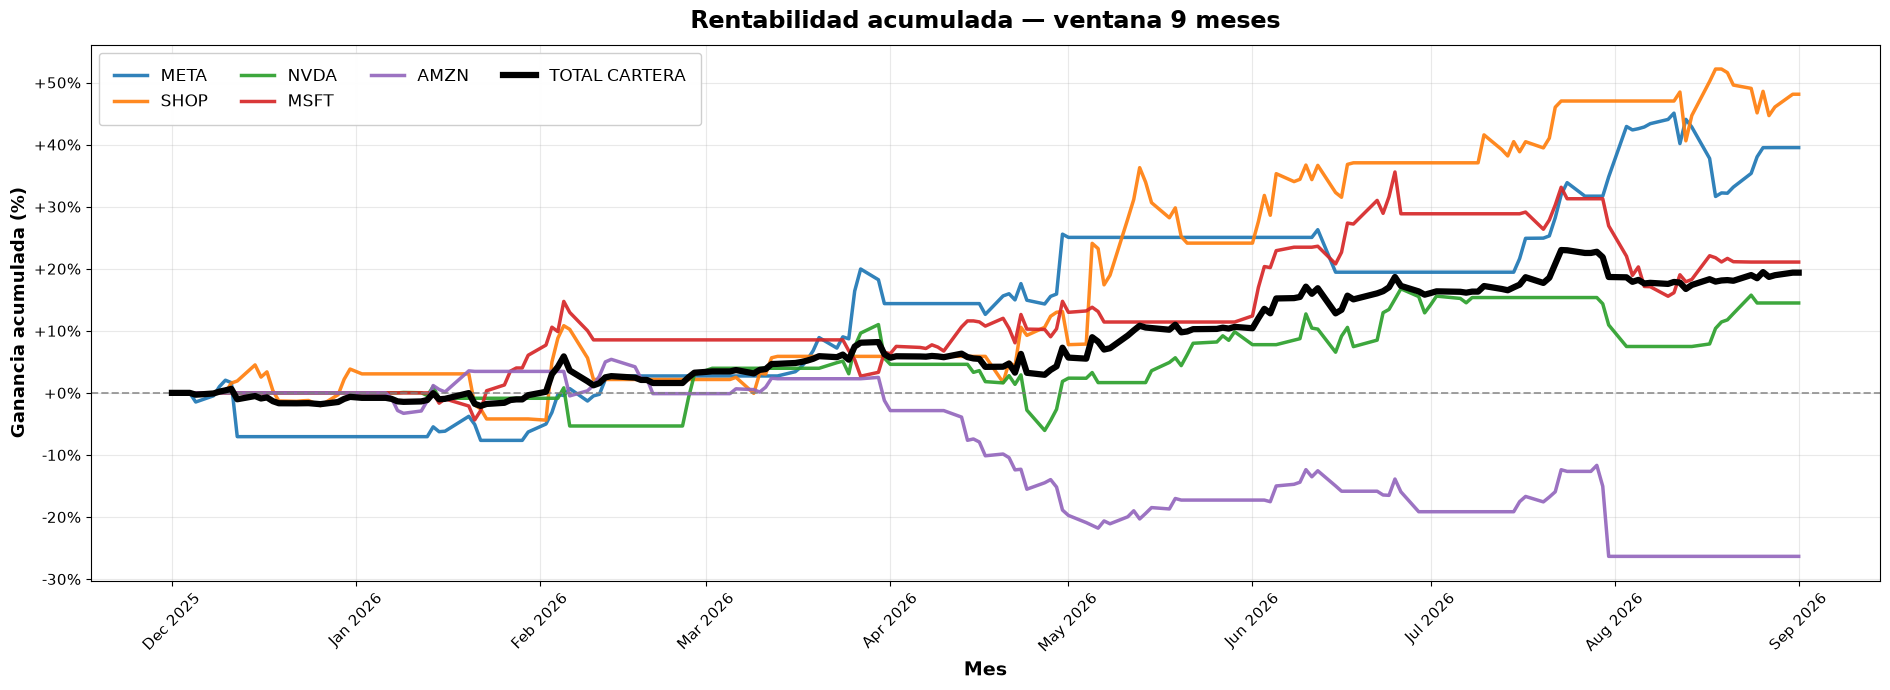

In [7]:
# ================= GRÁFICO RESUMEN DE RENTABILIDAD =================
# Todos los activos y la cartera total parten de 0 %, lo que permite comparar
# rentabilidades aunque los capitales iniciales asignados sean diferentes.
n = len(VENTANAS_MESES)
fig, axes = plt.subplots(n, 1, figsize=(19, max(7, 5.5 * n)), squeeze=False)

# BUCLE DE SUBGRÁFICAS: empareja cada eje con una ventana temporal activa.
for ax, meses in zip(axes[:, 0], VENTANAS_MESES):

    # BUCLE DE ACTIVOS: transforma cada curva monetaria en rentabilidad porcentual.
    for ticker in tickers:
        eq = resultados[meses][ticker]['Equity']['Equity']
        rentabilidad = (eq / capitales[ticker] - 1) * 100
        ax.plot(
            rentabilidad.index, rentabilidad, color=colores[ticker],
            lw=2.5, alpha=.92, label=ticker
        )

    # La línea negra representa el rendimiento agregado de toda la cartera.
    capital_total_inicial = sum(capitales.values())
    total = resultados[meses]['TOTAL CARTERA']['Equity']['Equity']
    rentabilidad_total = (total / capital_total_inicial - 1) * 100
    ax.plot(
        rentabilidad_total.index, rentabilidad_total,
        color='black', lw=4.5, label='TOTAL CARTERA', zorder=6
    )

    # Formato individual de cada subgráfica.
    ax.axhline(0, color='gray', ls='--', lw=1.4, alpha=.75)
    ax.set_title(
        f'Rentabilidad acumulada — ventana {meses} meses',
        fontsize=17, fontweight='bold', pad=12
    )
    ax.set_ylabel('Ganancia acumulada (%)', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0f}%'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.legend(
        loc='best', ncol=min(4, len(tickers) + 1),
        fontsize=12, framealpha=.96, borderpad=.9
    )
    ax.tick_params(axis='both', labelsize=11)
    ax.tick_params(axis='x', rotation=45)

# Etiqueta inferior compartida y exportación del resumen completo.
axes[-1, 0].set_xlabel('Mes', fontsize=14, fontweight='bold')
plt.tight_layout()
display(fig)
plt.close(fig)

## Interpretación y límites

- `FECHA_FIN_VENTANA` es el extremo final solicitado. Si no existe cotización exactamente ese día, la simulación utiliza la última sesión común anterior.
- Para una ventana de *n* meses se resta `relativedelta(months=n)` desde la sesión final común; la primera sesión real será la primera cotización disponible desde esa fecha objetivo.
- Cada activo utiliza únicamente el capital asignado en `ACTIVOS`; no se rebalancea ni transfiere dinero entre valores.
- Un activo puede tener una posición abierta al mismo tiempo que los demás.
- Si `CERRAR_AL_FINAL = False`, el fin de los datos no genera una salida: la fecha de salida queda vacía y el resultado se muestra como PnL latente valorado al último cierre.
- `Capital realizado` incorpora solo operaciones cerradas; `Capital final` incluye además la valoración de cualquier posición abierta.
- El resumen porcentual divide cada curva por su propio capital inicial. La línea negra divide el total por la suma de todos los capitales asignados.
- Los rendimientos se calculan en la moneda local de cada cotización. La fila total no incorpora fluctuaciones de divisa.
- El modelo admite fracciones teóricas de acciones; no comprueba lotes mínimos, margen ni disponibilidad para cortos.
- Los resultados históricos no garantizan rendimientos futuros.